# Retail Customer Segmentation with K-Means

This notebook is a portfolio-ready version of a customer segmentation exercise. The business goal is to identify actionable retail customer groups that can support CRM, marketing, loyalty, and digital engagement decisions.

The original academic notebook is not modified. This version keeps the useful modeling logic, but reframes the workflow as a market-oriented analytics case study.

## Business Framing

A retail company has customer-level data about purchase behavior, digital affinity, tenure, preferred channel, and region. Instead of treating every customer the same way, the company wants to discover natural customer groups and assign differentiated commercial actions.

This is an unsupervised learning problem: there is no predefined target label. K-Means is used to create segments from behavioral and value-related features, while channel and region are used later for interpretation.

In [1]:
from pathlib import Path
import runpy
import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
if (cwd / 'notebooks' / 'customer_segmentation_kmeans.py').exists():
    project_dir = cwd
elif (cwd / 'customer_segmentation_kmeans.py').exists():
    project_dir = cwd.parent
else:
    project_dir = Path('..').resolve()

script_path = project_dir / 'notebooks' / 'customer_segmentation_kmeans.py'
reports_dir = project_dir / 'reports'
figures_dir = project_dir / 'figures'

print(f'Project directory: {project_dir}')
print(f'Pipeline script: {script_path}')

Project directory: /Users/facundorodriguez/Desktop/repositorios-git/projects/retail-customer-segmentation
Pipeline script: /Users/facundorodriguez/Desktop/repositorios-git/projects/retail-customer-segmentation/notebooks/customer_segmentation_kmeans.py


## Run the Reproducible Pipeline

The Python script performs the full workflow: data loading, validation, feature engineering, scaling, K selection, K-Means fitting, PCA visualization, segment profiling, and export of figures/reports.

In [2]:
runpy.run_path(str(script_path), run_name='__main__')

Retail customer segmentation completed.
Rows: 830
Features: edad, ingreso_anual_usd, frecuencia_compra_mensual, ticket_promedio_usd, score_digital, antiguedad_meses, valor_mensual_estimado
Selected k: 5

Model selection:
 k     inertia  silhouette
 2 4013.080868    0.284695
 3 2842.031814    0.337846
 4 2074.515236    0.381448
 5 1686.277478    0.396305
 6 1568.678593    0.358030
 7 1463.286162    0.324256
 8 1389.731919    0.308628

Segment recommendations:
segment,business_label,customers,customer_share_pct,avg_monthly_value_usd,avg_digital_score,recommended_action
0,High-value loyal customers,158,19.04,856.44,73.27,"Prioritize loyalty benefits, premium bundles, and retention campaigns."
1,Affluent occasional customers,134,16.14,142.23,47.38,Use premium cross-selling and second-purchase incentives to increase frequency.
2,Established relationship customers,176,21.2,350.88,56.03,Protect retention with tenure-based benefits and relevant category recommendations.
3,Low-engagement price-

{'__name__': '__main__',
 '__doc__': None,
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/Users/facundorodriguez/Desktop/repositorios-git/projects/retail-customer-segmentation/notebooks/customer_segmentation_kmeans.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  

## Model Selection

K is evaluated using inertia and silhouette score. The final decision considers both quantitative quality and business interpretability.

In [3]:
model_selection = pd.read_csv(reports_dir / 'model_selection.csv')
model_selection

,k,inertia,silhouette
0,2,4013.080868,0.284695
1,3,2842.031814,0.337846
2,4,2074.515236,0.381448
3,5,1686.277478,0.396305
4,6,1568.678593,0.358030
5,7,1463.286162,0.324256
6,8,1389.731919,0.308628


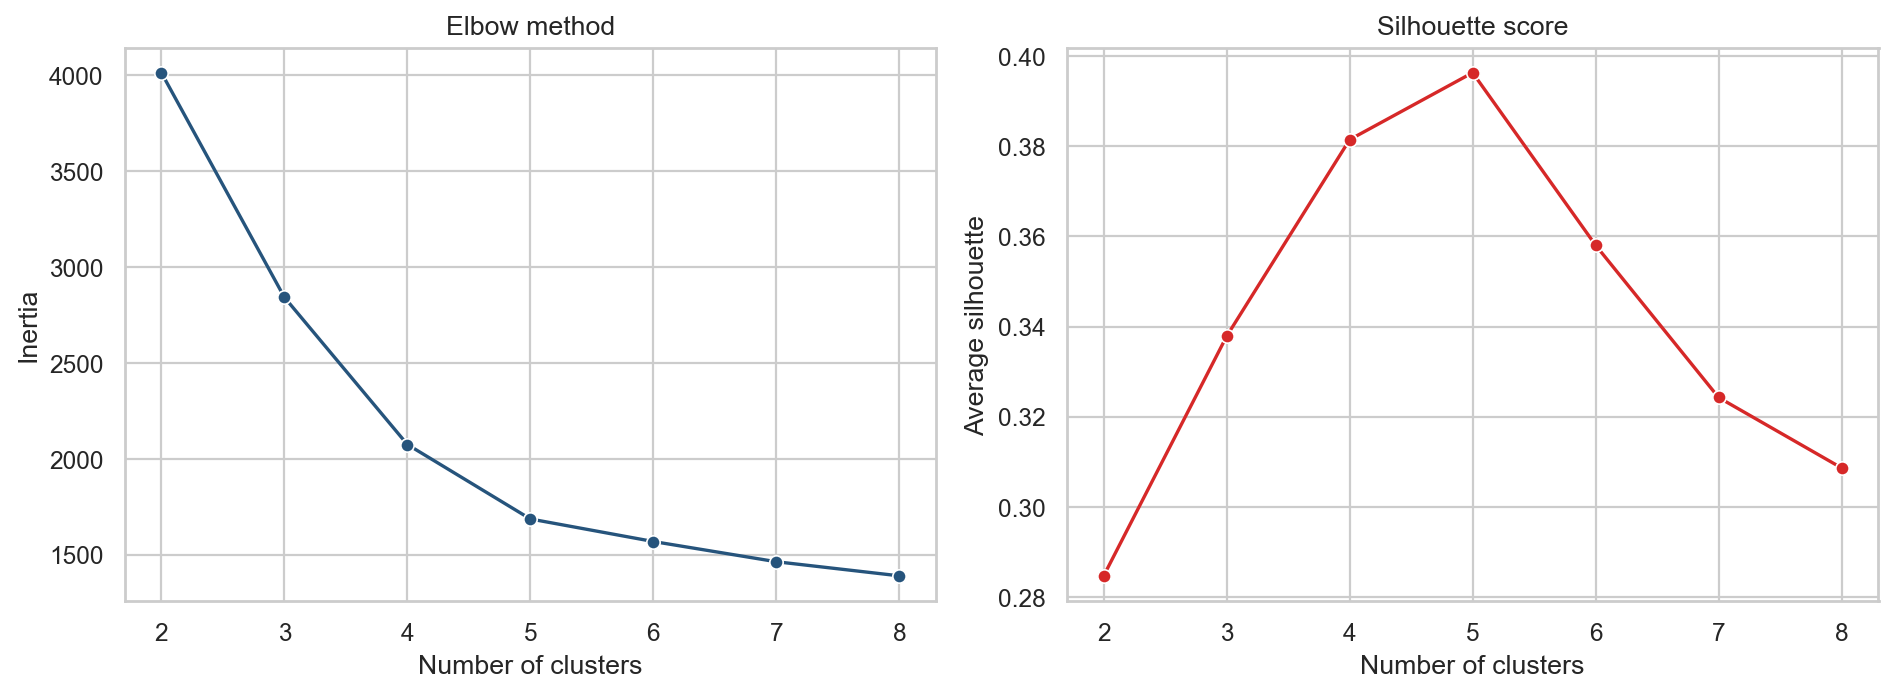

In [4]:
display(Image(filename=str(figures_dir / 'elbow_silhouette.png')))

## Segment Profiles

The following table translates clusters into business-readable customer profiles. Estimated monthly value is calculated as monthly purchase frequency multiplied by average ticket size.

In [5]:
profiles = pd.read_csv(reports_dir / 'segment_profiles.csv')
profiles

,segment,customers,avg_age,avg_income_usd,avg_purchase_frequency,avg_ticket_usd,avg_digital_score,avg_tenure_months,avg_monthly_value_usd,customer_share_pct
0,0,158,41.66,92485.38,7.28,118.01,73.27,45.19,856.44,19.04
1,1,134,45.47,99172.46,2.02,70.57,47.38,33.19,142.23,16.14
2,2,176,49.46,62151.56,4.24,82.92,56.03,58.32,350.88,21.20
3,3,179,39.54,37798.70,1.54,35.73,37.59,24.42,54.51,21.57
4,4,183,28.21,43209.10,6.02,48.70,87.74,18.50,293.21,22.05


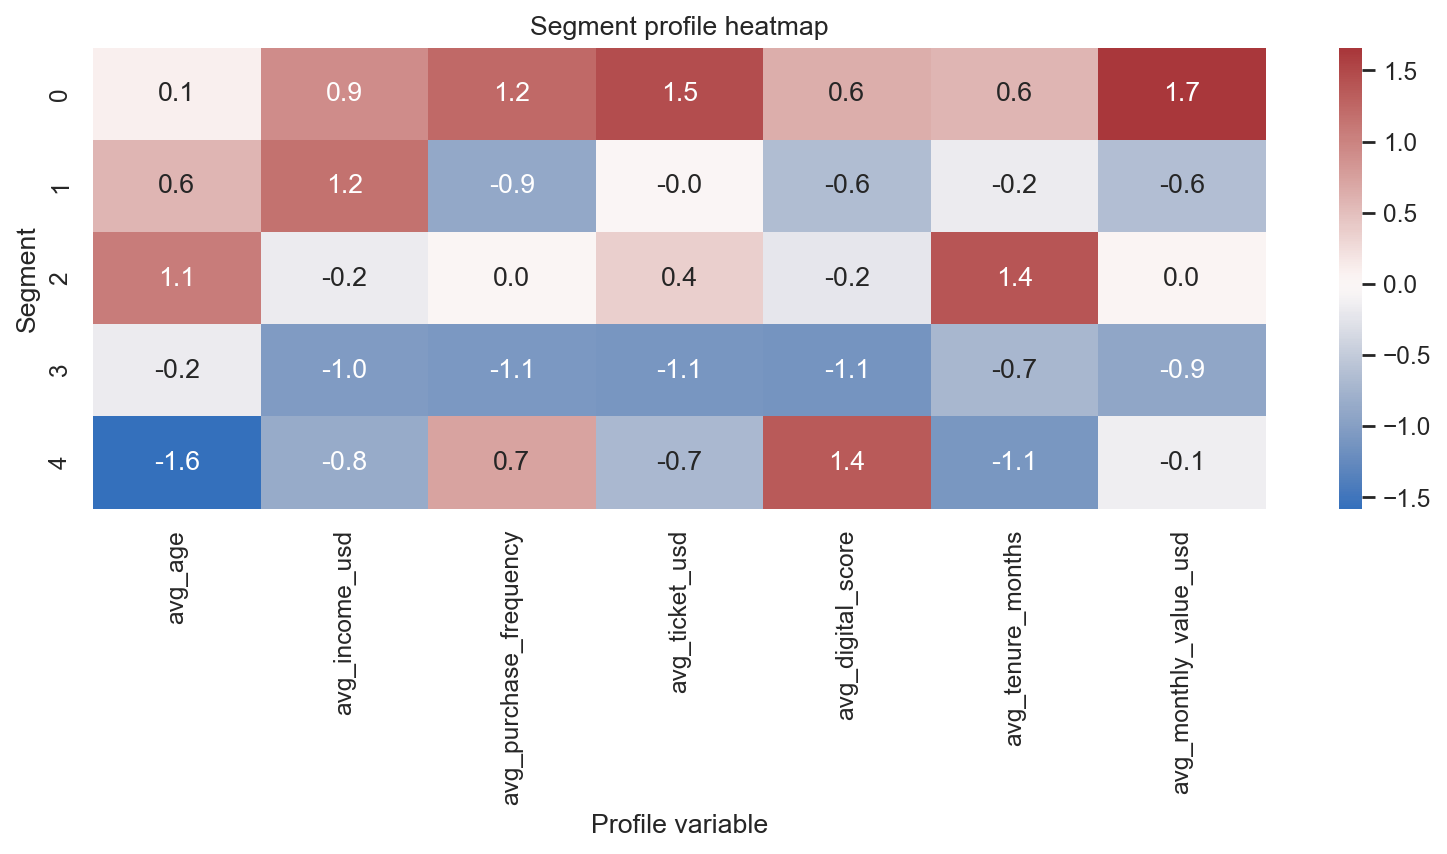

In [6]:
display(Image(filename=str(figures_dir / 'segment_profiles_heatmap.png')))

## Segment Visualization

PCA is used only for visualization. The clustering itself is fitted on the full scaled feature matrix.

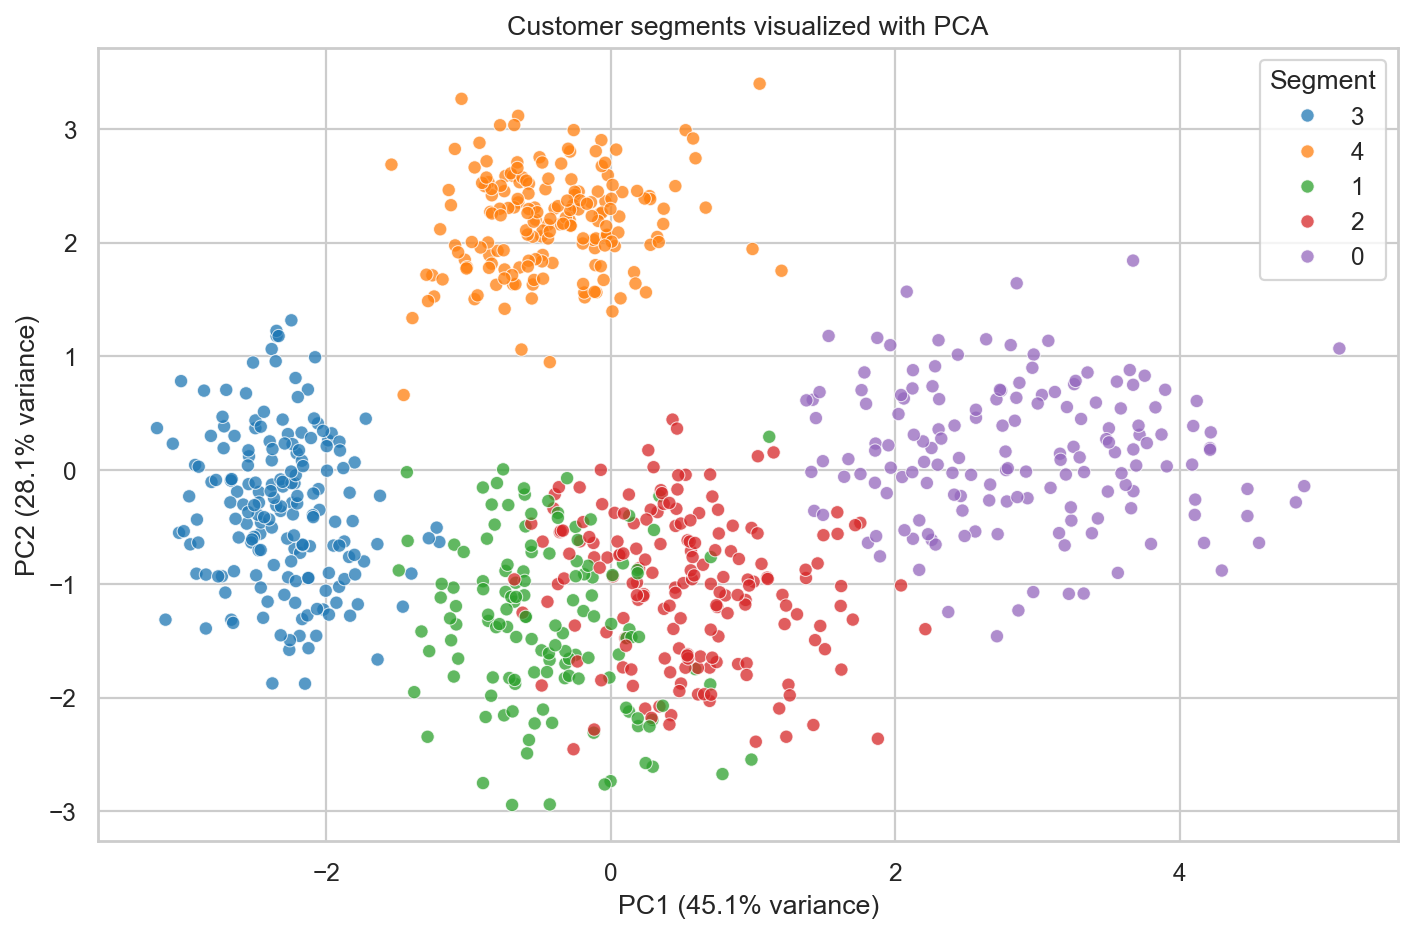

In [7]:
display(Image(filename=str(figures_dir / 'pca_customer_segments.png')))

## Business Recommendations

Each segment receives a market-oriented label and a concrete CRM or marketing action.

In [8]:
recommendations = pd.read_csv(reports_dir / 'segment_recommendations.csv')
recommendations

,segment,business_label,customers,customer_share_pct,avg_monthly_value_usd,avg_digital_score,recommended_action
0,0,High-value loyal customers,158,19.04,856.44,73.27,"Prioritize loyalty benefits, premium bundles, ..."
1,1,Affluent occasional customers,134,16.14,142.23,47.38,Use premium cross-selling and second-purchase ...
2,2,Established relationship customers,176,21.20,350.88,56.03,Protect retention with tenure-based benefits a...
3,3,Low-engagement price-sensitive customers,179,21.57,54.51,37.59,"Test reactivation offers, onboarding nudges, a..."
4,4,Digital-first frequent shoppers,183,22.05,293.21,87.74,"Use app/web campaigns, personalized recommenda..."


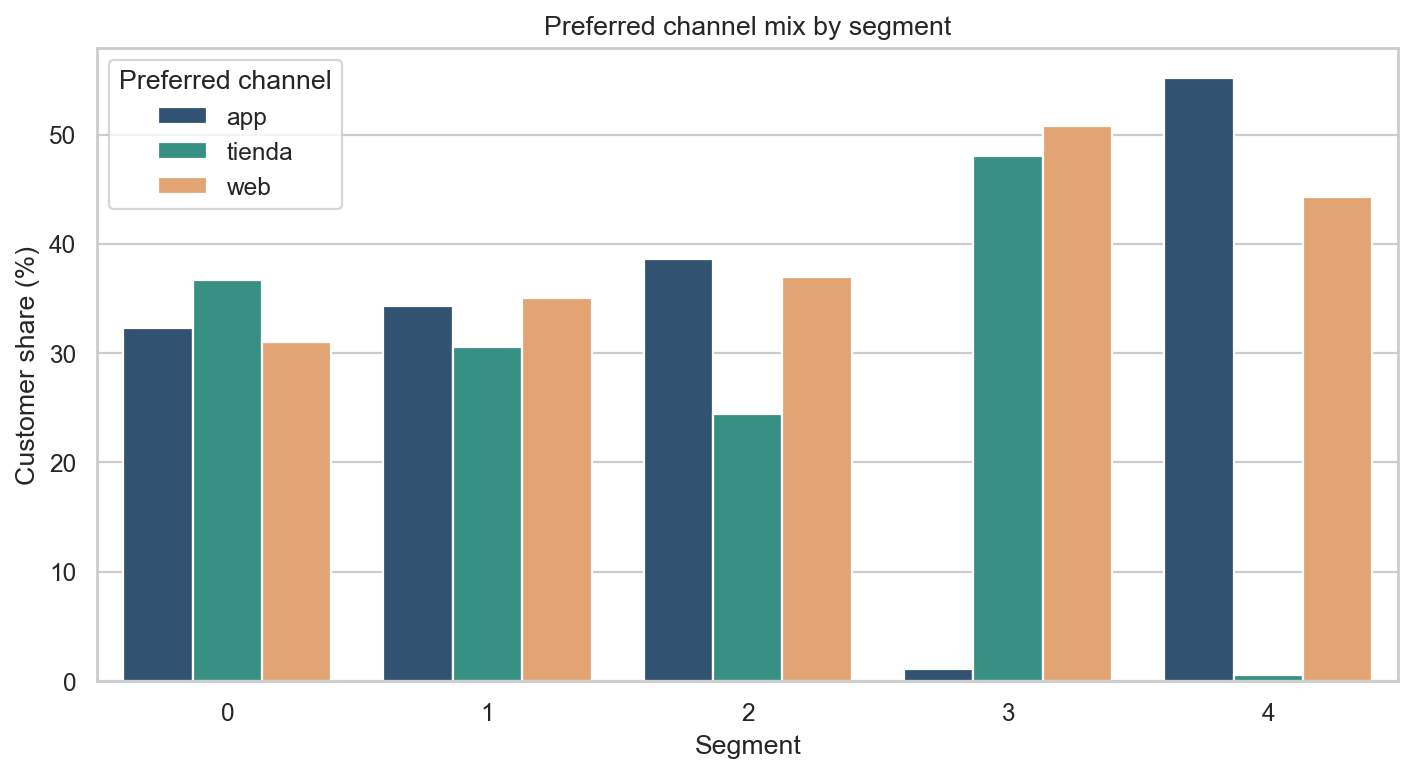

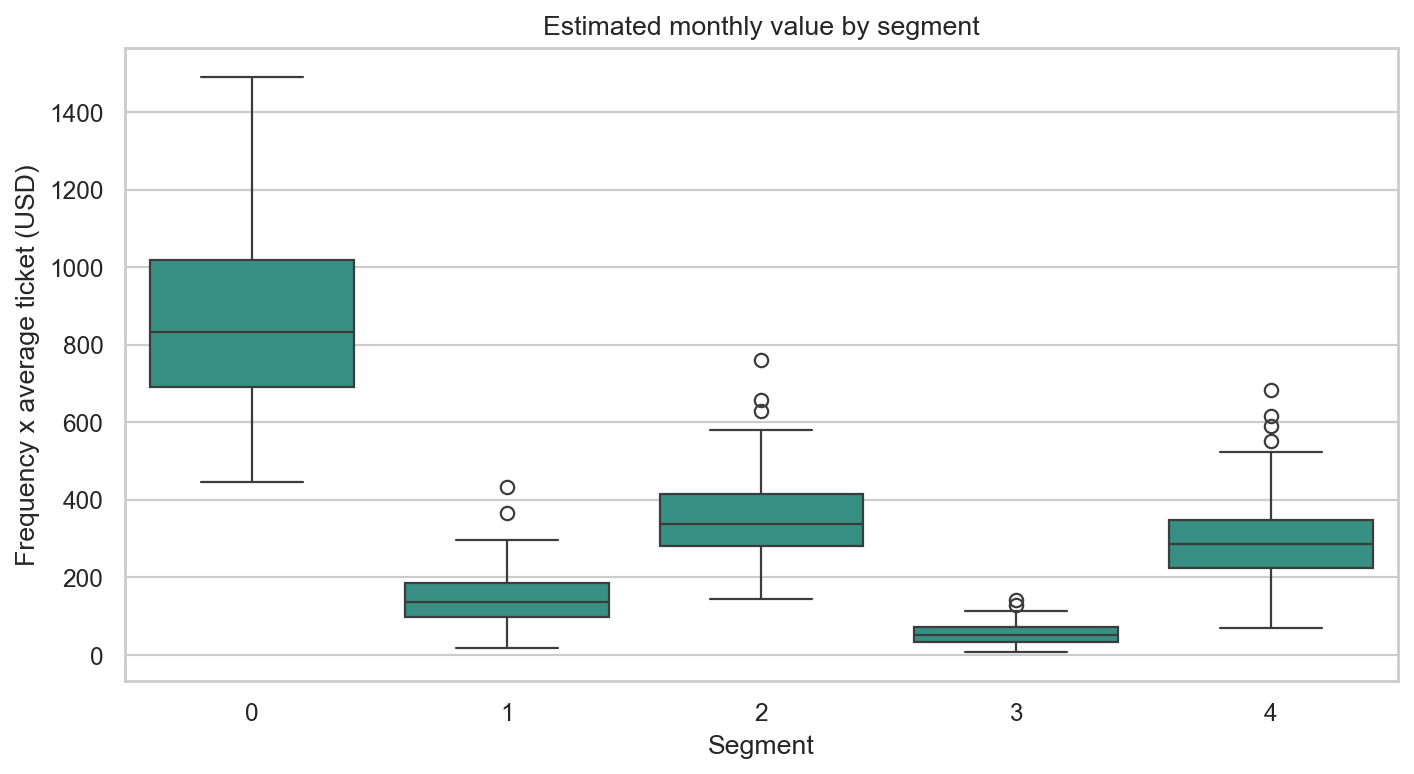

In [9]:
display(Image(filename=str(figures_dir / 'channel_mix_by_segment.png')))
display(Image(filename=str(figures_dir / 'monthly_value_by_segment.png')))

## Interpretation

This project shows how unsupervised learning can support customer strategy. K-Means is useful here as a first segmentation layer, but the segments should be validated with business experts and tested through real campaigns before operational deployment.

Important limitations: K-Means depends on scaling, the selected K, and the assumption that clusters are reasonably compact around centroids. It is best used as a decision-support tool rather than as an automatic replacement for commercial judgment.